# Première partie
### Exploration des données
#### Objectif : comprendre la structure du dataset

In [558]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [559]:
df = pd.read_csv('application_train.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [560]:
(df.isna().mean() * 100).sort_values(ascending=False)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
                              ...    
NAME_HOUSING_TYPE            0.000000
NAME_FAMILY_STATUS           0.000000
NAME_EDUCATION_TYPE          0.000000
NAME_INCOME_TYPE             0.000000
SK_ID_CURR                   0.000000
Length: 122, dtype: float64

In [561]:
# Comptage des classes dans TARGET
target_counts = df['TARGET'].value_counts(normalize=True)
target_counts

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

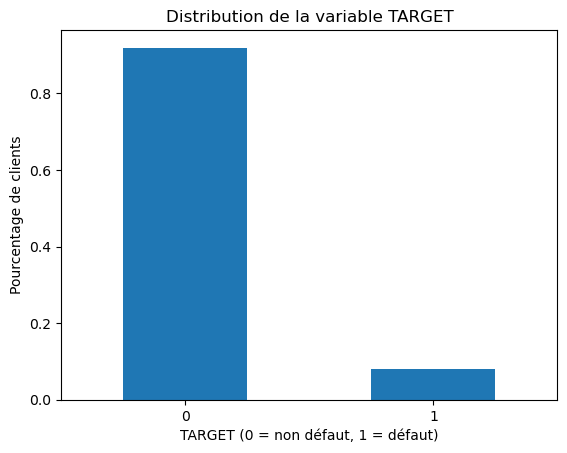

In [562]:
# Bar plot
target_counts.sort_index().plot(kind = 'bar')
plt.title('Distribution de la variable TARGET')
plt.xlabel('TARGET (0 = non défaut, 1 = défaut)')
plt.ylabel('Pourcentage de clients')
plt.xticks(rotation=0)
plt.show()

Le taux de défaut est d'environ 8%, ce qui est cohérent avec un portefeuille de crédit de détail. 
Le problème est donc totalement déséquilibré, ce qui justifie l'utilisation de métriques adaptées au risque plutôt que l'accuracy.

Ici, l'utilisation de l'accuracy n'est pas recommandée pour plusieurs raisons. 
La première c'est que le score d'accuracy sera toujours excellent étant donnée le faible taux de défaut.
La seconde serait que les erreurs possibles n'ont pas le même coût. En effet, on peut refuser un bon client ou bien accepter un mauvais client et les effets ne sont pas les mêmes.

### Conclusion

Un taux de défaut d’environ 8 % correspond à un portefeuille de risque modéré pour une banque de détail.
Bien que la majorité des clients soient solvables, le coût potentiel des défauts justifie une grande prudence.
La banque a donc intérêt à mettre en place une stratégie de décision différenciée, avec un refus des profils les plus risqués et une analyse renforcée pour les clients intermédiaires.

# Deuxième partie
### Analyse et compréhension du risque

Différentes variables influes sur la définition du risque parmis lesquelles on retrouve : l'age, le revenu, ou encore le montant du crédit.
La première variable sur laquelle nous allons nous concentrer est la variable de l'âge. En effet, l'âge est fortement lié à la stabilité financière et au cycle de vie du client. Les profils plus jeunes peuvent représenter un risque de part une situation professionnelle encore instable tandis que les profils plus agés voient leur capacité de remboursement diminuer, notamment à l'approche de la retraite.

L’âge du client est calculé à partir de la variable DAYS_BIRTH, exprimée en nombre de jours avant la demande de crédit.

In [563]:
# Etude de l'âge du client
df['AGE'] = (-df['DAYS_BIRTH'] / 365).round(1)
df['AGE'].describe()

count    307511.000000
mean         43.936992
std          11.956084
min          20.500000
25%          34.000000
50%          43.200000
75%          53.900000
max          69.100000
Name: AGE, dtype: float64

Text(0.5, 1.0, "Distribution de l'âge des clients")

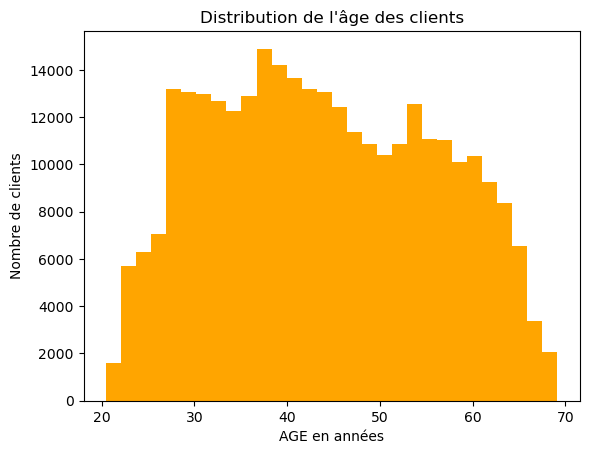

In [564]:
plt.hist(df['AGE'], bins = 30, color = 'orange')
plt.xlabel('AGE en années')
plt.ylabel('Nombre de clients')
plt.title("Distribution de l'âge des clients")

La disribution de l'âge montre un portefeuille principalement composé de personnes en âge d'activité, ce qui est cohérent avec notre problème.

In [565]:
# Voici la comparaison entre clients en défaut et non-défaut permet d’identifier des tranches d’âge associées à un risque plus élevé.

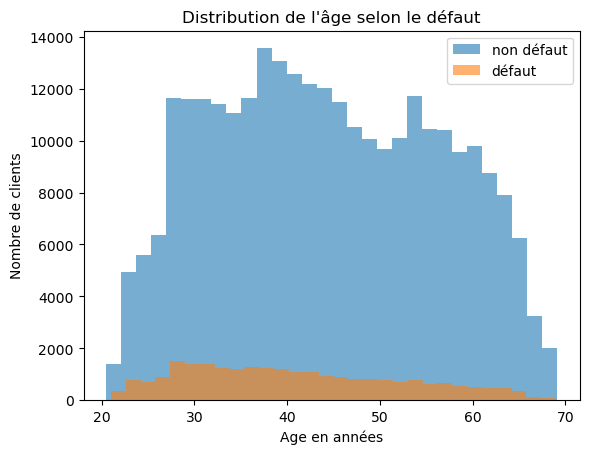

In [566]:
plt.hist(df[df['TARGET'] == 0]['AGE'], bins = 30, alpha = 0.6, label = 'non défaut')
plt.hist(df[df['TARGET'] == 1]['AGE'], bins = 30, alpha = 0.6, label = 'défaut')

plt.title("Distribution de l'âge selon le défaut")
plt.xlabel('Age en années')
plt.ylabel('Nombre de clients')
plt.legend()
plt.show()

Les défauts semblent davantage représentés chez les clients âgés de 25 à 40 ans.
Toutefois, cette observation doit être interprétée avec prudence, car elle peut refléter une plus forte concentration de clients dans cette tranche d’âge.
Aucun pic de risque net n’est observé, ce qui suggère que l’âge seul n’est pas un facteur discriminant suffisant.

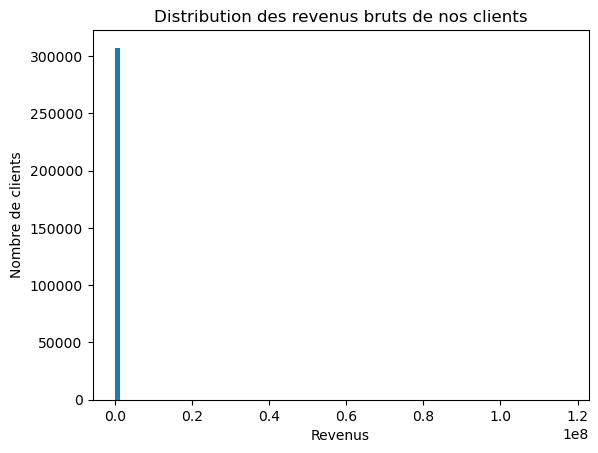

In [567]:
# Affichage de la distribution brute

plt.hist(df['AMT_INCOME_TOTAL'], bins = 100)
plt.title('Distribution des revenus bruts de nos clients')
plt.xlabel('Revenus')
plt.ylabel('Nombre de clients')
plt.show()

La distribution des revenus est fortement asymétrique, avec quelques valeurs extrêmement élevées.
Une transformation logarithmique est donc utilisée afin de rendre la distribution lisible et exploitable lors de l’analyse exploratoire

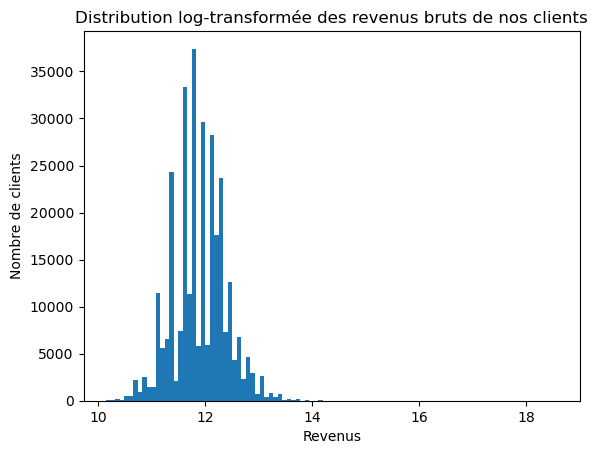

In [568]:
# Passage au logarithme pour réduire l'asymétrie de la distribution et la rendre plus lisible

plt.hist(np.log1p(df['AMT_INCOME_TOTAL']), bins = 100)
plt.title('Distribution log-transformée des revenus bruts de nos clients')
plt.xlabel('Revenus')
plt.ylabel('Nombre de clients')
plt.show()

La majorité des clients se situe dans une tranche de revenus intermédiaires, avec une dispersion modérée. Les très hauts revenus sont rares et constituent des cas particuliers à analyser séparément.

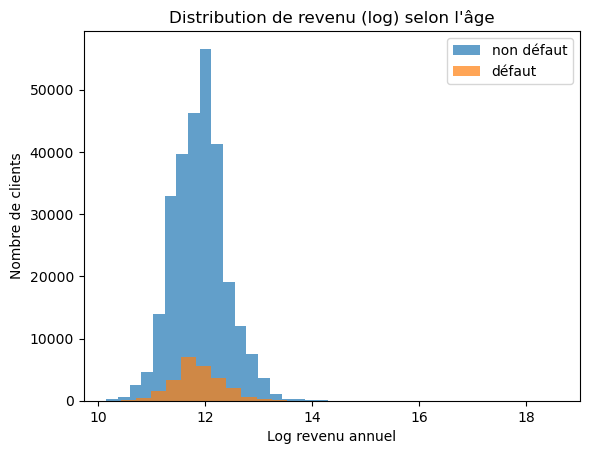

In [569]:
df['LOG_INCOME'] = np.log1p(df['AMT_INCOME_TOTAL'])

plt.hist(df[df['TARGET'] == 0]['LOG_INCOME'], bins = 30, alpha = 0.7, label = 'non défaut')
plt.hist(df[df['TARGET'] == 1]['LOG_INCOME'], bins = 30, alpha = 0.7, label = 'défaut')
plt.title("Distribution de revenu (log) selon l'âge")
plt.xlabel('Log revenu annuel')
plt.ylabel('Nombre de clients')
plt.legend()
plt.show()

Le risque de défaut est attendu plus élevé pour les clients à faibles revenus, en raison d’une capacité de remboursement limitée.
Toutefois, des revenus élevés ne garantissent pas l’absence de risque, notamment lorsque les montants empruntés et les mensualités augmentent.
La relation entre revenu et risque est donc non linéaire et s’exprime plutôt par des effets de seuil.

La visualisation du risque par revenu est réalisée par tranches afin de calculer un taux de défaut comparable entre segments, indépendamment du volume de clients.

In [570]:
# On découpe le dataset en 5 tranches équivalentes en fonction de la colonne AMT INCOME TOTAL

df['LOG_INCOME_BIN'] = pd.qcut(df['LOG_INCOME'], q=5)

In [571]:
# Calcul du taux de défaut par tranche

defaut_rate_by_income = ( df.groupby('LOG_INCOME_BIN')['TARGET'].mean().reset_index() )

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\2006388801.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defaut_rate_by_income = ( df.groupby('LOG_INCOME_BIN')['TARGET'].mean().reset_index() )


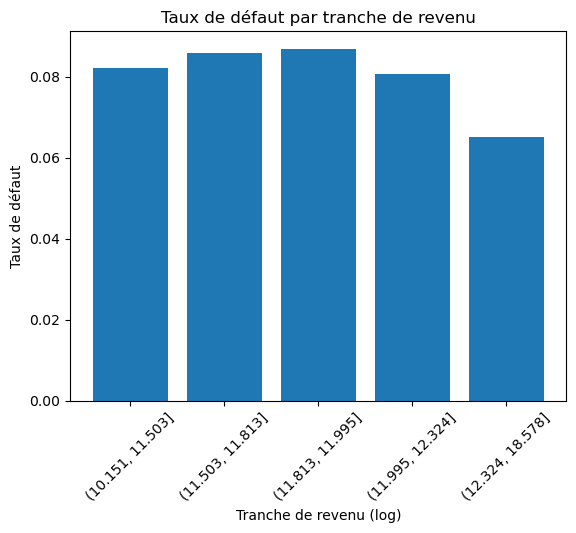

In [572]:
plt.bar(
    defaut_rate_by_income['LOG_INCOME_BIN'].astype(str),
    defaut_rate_by_income['TARGET']
)

plt.title('Taux de défaut par tranche de revenu')
plt.xlabel('Tranche de revenu (log)')
plt.ylabel('Taux de défaut')
plt.xticks(rotation=45)
plt.show()

Le revenu, pris isolément, ne semble pas fortement discriminant pour expliquer le risque de défaut sur la majorité du portefeuille, les trois premières tranches présentant des taux de défaut proches.
En revanche, les clients appartenant à la tranche de revenus la plus élevée présentent un risque significativement plus faible, ce qui suggère un effet protecteur des très hauts revenus.

# Construction d'indicateurs

Naturellement, le risque de défaut est attendu relativement stable pour des niveaux de taux d’endettement modérés, puis augmente fortement au-delà de certains seuils, traduisant une perte rapide de capacité d’absorption des chocs financiers.

Notre premier indicateur construit sera un DTI approximatif par manque de données dans application_train. Le DTI est simplement le rapport du montant annuel de toutes les dettes du client sur son revenu annuel. 

In [573]:
# Construction d'un DTI approximatif (Nous avons uniquement des infos sur le crédit immobilier)

df['DTI_approx'] = df['AMT_ANNUITY'] / ( df['AMT_INCOME_TOTAL'] + 1)

Bien que le DTI soit théoriquement compris entre 0 et 1, des valeurs extrêmes peuvent apparaître dans les données réelles en raison de revenus très faibles ou de situations atypiques. Pour des soucis de division par 0, j'ai décidé d'ajouter 1 au dénominateur. Cet ajout ne modifiera pas le fond du problème étant donnée l'ordre de grandeur des revenus annuels.

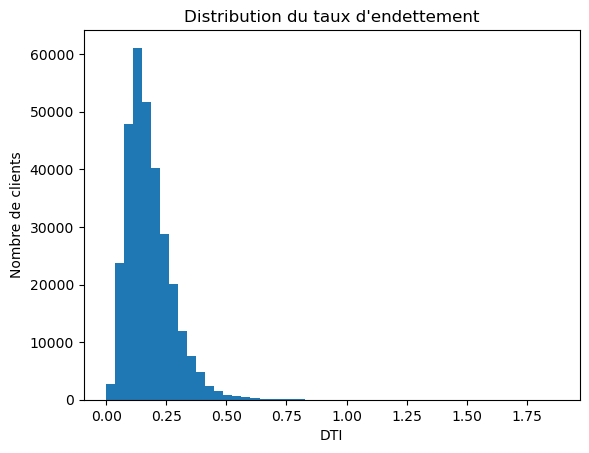

In [574]:
plt.hist(df['DTI_approx'], bins = 50)
plt.title("Distribution du taux d'endettement")
plt.xlabel("DTI")
plt.ylabel("Nombre de clients")
plt.show()

In [575]:
# Traitement des valeurs extrêmes pour maximiser la compréhension et la prise de décision

dti_cap = df['DTI_approx'].quantile(0.99)
df_dti = df[df['DTI_approx'] < dti_cap]

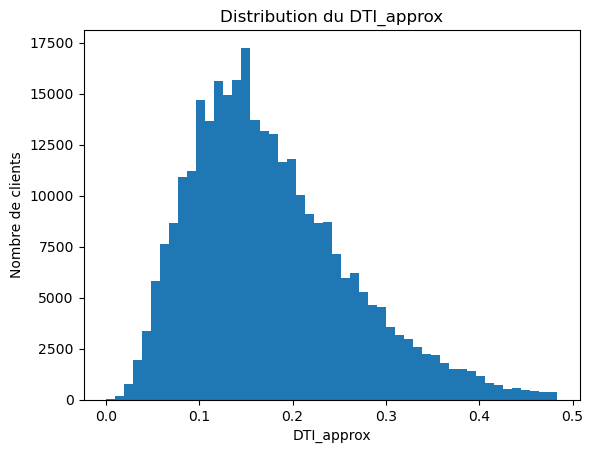

In [576]:
plt.hist(df_dti['DTI_approx'], bins = 50)
plt.title("Distribution du DTI_approx")
plt.xlabel("DTI_approx")
plt.ylabel("Nombre de clients")
plt.show()

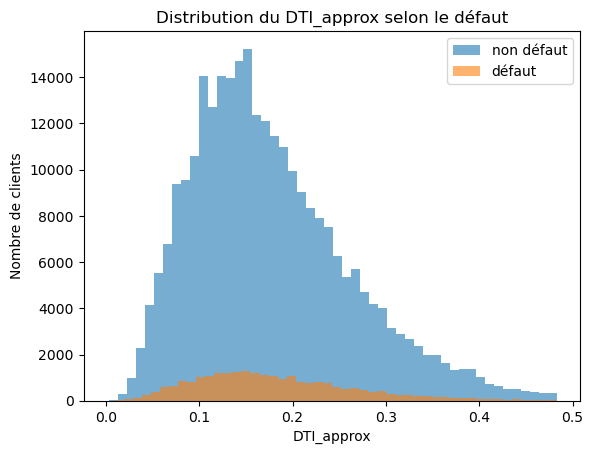

In [577]:
plt.hist(df_dti[df_dti['TARGET']==0]['DTI_approx'], bins = 50, alpha = 0.6, label = 'non défaut')
plt.hist(df_dti[df_dti['TARGET']==1]['DTI_approx'], bins = 50, alpha = 0.6, label = 'défaut')

plt.title('Distribution du DTI_approx selon le défaut')
plt.xlabel('DTI_approx')
plt.ylabel('Nombre de clients')
plt.legend()
plt.show()

In [578]:
# Maintenant, nous allons diviser le DTI_approx en tranche

bins = [0, 0.13, 0.20, 0.30, 1]
labels = ["0-13%", "13-20%", "20-30%", "30%+"]
df_dti['DTI_BIN'] = pd.cut(df_dti['DTI_approx'], bins = bins, labels = labels)
default_rate_by_dti = (df_dti.groupby('DTI_BIN')['TARGET'].mean())

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\995159974.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dti['DTI_BIN'] = pd.cut(df_dti['DTI_approx'], bins = bins, labels = labels)
C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\995159974.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate_by_dti = (df_dti.groupby('DTI_BIN')['TARGET'].mean())


In [579]:
result = df_dti.groupby('DTI_BIN').agg(nb_clients = ('TARGET', 'count'), taux_defaut = ('TARGET', 'mean'))
result

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\3021587611.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df_dti.groupby('DTI_BIN').agg(nb_clients = ('TARGET', 'count'), taux_defaut = ('TARGET', 'mean'))


,nb_clients,taux_defaut
DTI_BIN,,
0-13%,100449,0.073948
13-20%,101992,0.082144
20-30%,73742,0.087643
30%+,28241,0.082221


Le taux de défaut augmente globalement en fonction du DTI_approx, ce qui confirme l'importance de la capacité de remboursement dans l'évaluation du risque.
Toutefois, la relation n'est pas parfaite et dépend de la taille des échantillons dans chaque tranche.

In [580]:
# Dans cette partie, nous allons analyser le comportement du taux de défaut en combinant 3 variables : AGE, AMT_TOTAL_INCOME & DTI_approx

df_dti['AGE'] = -df_dti['DAYS_BIRTH'] / 365

age_bins = [18, 30, 40, 60, 100]
df_dti['AGE_BIN'] = pd.cut(df_dti['AGE'], bins = age_bins)

income_bins = [0, 50000, 100000, 200000, 750000]
df_dti['INCOME_BIN'] = pd.cut(df_dti['AMT_INCOME_TOTAL'], bins = income_bins)

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\3487286552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dti['AGE'] = -df_dti['DAYS_BIRTH'] / 365
C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\3487286552.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dti['AGE_BIN'] = pd.cut(df_dti['AGE'], bins = age_bins)
C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\3487286552.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

## Heatmap de 2 variables combinées parmi les 3 en face du taux de défaut 

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\3329433895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df_dti.groupby(['DTI_BIN', 'AGE_BIN'])['TARGET'].mean().unstack()


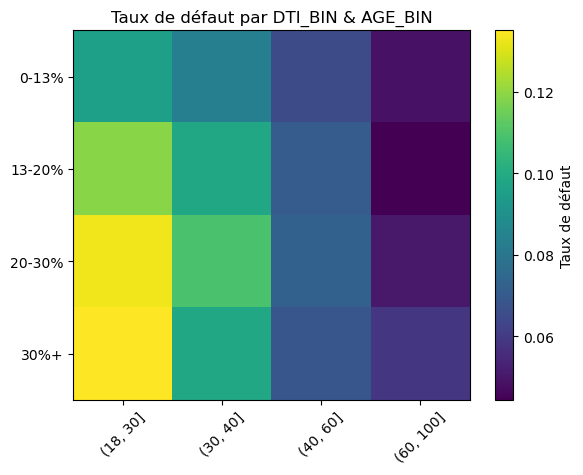

In [581]:
result = df_dti.groupby(['DTI_BIN', 'AGE_BIN'])['TARGET'].mean().unstack()

plt.imshow(result, aspect = 'auto')
plt.colorbar(label='Taux de défaut')
plt.xticks(range(len(result.columns)), result.columns, rotation = 45)
plt.yticks(range(len(result.index)), result.index)
plt.title('Taux de défaut par DTI_BIN & AGE_BIN')
plt.show()

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\61270350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df_dti.groupby( ['AGE_BIN', 'INCOME_BIN'] )['TARGET'].mean().unstack()


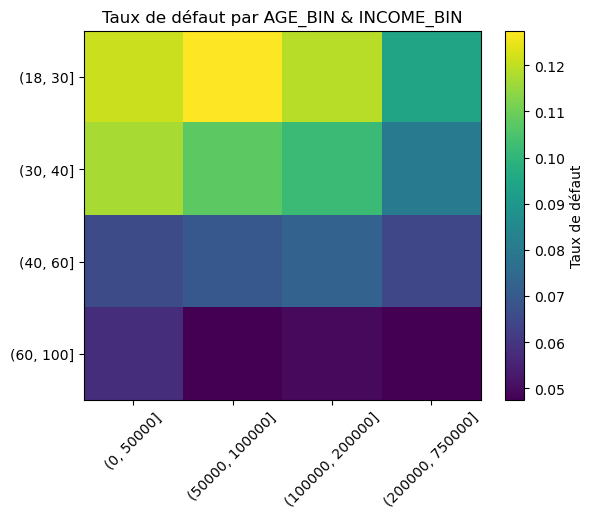

In [582]:
result = df_dti.groupby( ['AGE_BIN', 'INCOME_BIN'] )['TARGET'].mean().unstack()

plt.imshow(result, aspect = 'auto')
plt.colorbar(label='Taux de défaut')
plt.xticks(range(len(result.columns)), result.columns, rotation = 45)
plt.yticks(range(len(result.index)), result.index)
plt.title('Taux de défaut par AGE_BIN & INCOME_BIN')
plt.show()

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\112174916.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df_dti.groupby( ['DTI_BIN', 'INCOME_BIN'] )['TARGET'].mean().unstack()


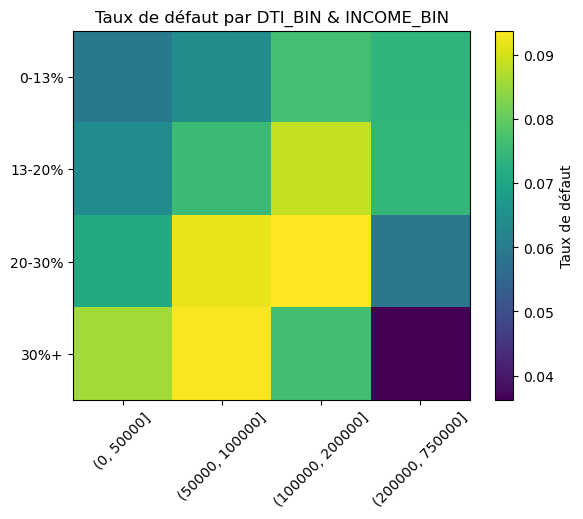

In [583]:
result = df_dti.groupby( ['DTI_BIN', 'INCOME_BIN'] )['TARGET'].mean().unstack()

plt.imshow(result, aspect = 'auto')
plt.colorbar(label='Taux de défaut')
plt.xticks(range(len(result.columns)), result.columns, rotation = 45)
plt.yticks(range(len(result.index)), result.index)
plt.title('Taux de défaut par DTI_BIN & INCOME_BIN')
plt.show()

L'analyse combinée de l’âge, du revenu et du DTI_approx montre que le risque de défaut est plus élevé chez les clients jeunes avec un taux d’endettement important. Les clients ayant des revenus intermédiaires semblent également présenter un risque accru, notamment lorsque leur DTI dépasse 20 %. Ces résultats confirment l’importance d’analyser conjointement plusieurs variables pour évaluer le risque de crédit.

## Heatmap globale pour une vue d'ensemble

C:\Users\Alexis\AppData\Local\Temp\ipykernel_10316\1025155554.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df_dti.groupby( ['DTI_BIN', 'AGE_BIN', 'INCOME_BIN'] )['TARGET'].mean().unstack()


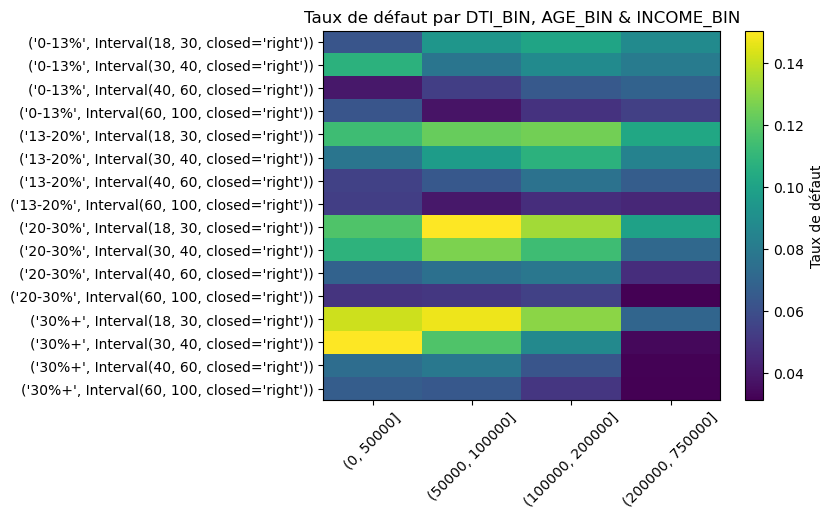

In [584]:
result = df_dti.groupby( ['DTI_BIN', 'AGE_BIN', 'INCOME_BIN'] )['TARGET'].mean().unstack()

plt.imshow(result, aspect = 'auto')
plt.colorbar(label='Taux de défaut')
plt.xticks(range(len(result.columns)), result.columns, rotation = 45)
plt.yticks(range(len(result.index)), result.index)
plt.title('Taux de défaut par DTI_BIN, AGE_BIN & INCOME_BIN')
plt.show()

# MODELISATION : Machine Learning

Les variables de capacité financière telles que le taux d’endettement, l'âge et le revenu sont incluses en priorité, car elles présentent un signal plus direct sur le risque de défaut d'un point de vue business.

In [585]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [586]:
features = ['AGE', 'LOG_INCOME', 'DTI_approx']
data = df_dti[features + ['TARGET']]

In [587]:
X = data[features]
y = data['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [588]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [589]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [590]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0] })

coefficients.sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
2,DTI_approx,0.052994
1,LOG_INCOME,-0.077273
0,AGE,-0.300624


In [591]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('ROC-AUC :', roc_auc)

ROC-AUC : 0.5901688072111105


Un modèle de régression logistique utilisant uniquement l’âge, le revenu et le DTI obtient un ROC-AUC de 0.59. Ce score montre que ces variables contiennent une information sur le risque de crédit mais restent insuffisantes pour une prédiction précise, ce qui souligne l’importance d’autres données historiques.

# Ajout de données supplémentaires

La table bureau contient l'historique des crédits accordés aux clients et les potentiels défauts associés. Prenons en compte ces données pour améliorer notre modèle de base.

In [592]:
bureau = pd.read_csv('bureau.csv')
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [593]:
# Collectons des données pertinentes à partir de la table bureau en créant des indicateurs

nb_credits = bureau.groupby('SK_ID_CURR').size().rename('BUREAU_NB_CREDITS')  #Total de crédits enregistrés
nb_active = bureau['CREDIT_ACTIVE'].eq('Active').groupby(bureau['SK_ID_CURR']).sum().rename('BUREAU_NB_ACTIVE') #Nombre de crédits actifs
nb_closed = bureau['CREDIT_ACTIVE'].eq('Closed').groupby(bureau['SK_ID_CURR']).sum().rename('BUREAU_NB_CLOSED') #Nombre de crédits clos
has_overdue = (bureau['CREDIT_DAY_OVERDUE'].gt(0).groupby(bureau['SK_ID_CURR'])
               .max().astype(int).rename('BUREAU_HAS_OVERDUE')) #Au moins un crédit avec un retard > 0 jours
nb_overdue_credits = (bureau['CREDIT_DAY_OVERDUE'].gt(0).groupby(bureau['SK_ID_CURR'])
                      .sum().rename('BUREAU_NB_OVERDUE_CREDITS')) #Nombre de crédits en retard

In [594]:
# Création d'un nouveau dataset à partir des données agrégées du dataset bureau

bureau_features = pd.concat([nb_credits, nb_active, nb_closed, has_overdue, nb_overdue_credits], axis = 1).reset_index()
bureau_features.head()

,SK_ID_CURR,BUREAU_NB_CREDITS,BUREAU_NB_ACTIVE,BUREAU_NB_CLOSED,BUREAU_HAS_OVERDUE,BUREAU_NB_OVERDUE_CREDITS
0,100001,7,3,4,0,0
1,100002,8,2,6,0,0
2,100003,4,1,3,0,0
3,100004,2,0,2,0,0
4,100005,3,2,1,0,0


In [595]:
# Je rajoute la colonne 'SK_ID_CURR' pour merger les 2 datasets

df = df_dti[['SK_ID_CURR'] + features + ['TARGET']] 
df = df.merge(
    bureau_features,
    on='SK_ID_CURR',
    how='left')

df.head()

,SK_ID_CURR,AGE,LOG_INCOME,DTI_approx,TARGET,BUREAU_NB_CREDITS,BUREAU_NB_ACTIVE,BUREAU_NB_CLOSED,BUREAU_HAS_OVERDUE,BUREAU_NB_OVERDUE_CREDITS
0,100002,25.920548,12.218500,0.121977,1,8.0,2.0,6.0,0.0,0.0
1,100003,45.931507,12.506181,0.132216,0,4.0,1.0,3.0,0.0,0.0
2,100004,52.180822,11.119898,0.099999,0,2.0,0.0,2.0,0.0,0.0
3,100006,52.068493,11.813037,0.219898,0,NaN,NaN,NaN,NaN,NaN
4,100007,54.608219,11.707678,0.179961,0,1.0,0.0,1.0,0.0,0.0


In [596]:
# Certains clients peuvent être nouveau. De ce fait, aucun historique n'est disponible et donc des NaN peuvent être présents.
df.isna().sum()

SK_ID_CURR                       0
AGE                              0
LOG_INCOME                       0
DTI_approx                       0
TARGET                           0
BUREAU_NB_CREDITS            43386
BUREAU_NB_ACTIVE             43386
BUREAU_NB_CLOSED             43386
BUREAU_HAS_OVERDUE           43386
BUREAU_NB_OVERDUE_CREDITS    43386
dtype: int64

In [597]:
# Construction d'une variable indiquant si oui ou non, le  client fait parti de l'historique de nos demandes de crédit
df['HAS_BUREAU_HISTORY'] = df['BUREAU_NB_CREDITS'].notna().astype(int)

In [598]:
# Remplacement des NaN par des 0 car nous avons l'information sur l'historique
df = df.fillna(0)

In [599]:
df.groupby('HAS_BUREAU_HISTORY')['TARGET'].mean()

HAS_BUREAU_HISTORY
0    0.101116
1    0.077399
Name: TARGET, dtype: float64

In [600]:
## Les clients sans historique présentent un risque plus élevé (jeune âge, jamais emprunté...) que ceux ayant déjà un historique. 
## (HAS_BUREAU_HISTORY = 0 → 10.1 % défaut & HAS_BUREAU_HISTORY = 1 → 7.7 % défaut)

In [601]:
X = df.drop(columns = ['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify = y)

In [602]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [603]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [604]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('ROC-AUC:', roc_auc)

ROC-AUC: 0.6274474671790713


In [605]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
4,BUREAU_NB_ACTIVE,0.314394
7,BUREAU_NB_OVERDUE_CREDITS,0.081171
2,DTI_approx,0.072612
3,BUREAU_NB_CREDITS,-0.006464
6,BUREAU_HAS_OVERDUE,-0.014152
1,LOG_INCOME,-0.085704
8,HAS_BUREAU_HISTORY,-0.147574
5,BUREAU_NB_CLOSED,-0.211637
0,AGE,-0.283476


In [606]:
# Ajout d'un nouveau dataset : previous application

previous_appli = pd.read_csv('previous_application.csv')
previous_appli.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


Dans un premier temps, nous allons nous concentrer sur 3 nouvelles variables. 
Nous allons travailler avec NB_PREV_APP, NB_REFUSED et AVG_AMT_APPLICATION. Ces 3 variables contiennent les informations suivantes : Nombre d'anciennes demandes, Nombre de demandes refusées et le montant moyen demandé. Nous adoptons cette stratégie pour garder de la clarté dans le choix de nos variables et leur importance dans notre modèle d'attribution.

In [607]:
# Extraction des 3 variables qui nous intéressent

nb_prev_app = previous_appli.groupby('SK_ID_CURR').size().rename('NB_PREV_APP') # Nombre total de demandes ( liste des SK_ID_CURR )
nb_refused = previous_appli['NAME_CONTRACT_STATUS'].eq('Refused').groupby(previous_appli['SK_ID_CURR']).sum().rename('NB_REFUSED') # Nombre de refus
avg_amt_app = previous_appli.groupby('SK_ID_CURR')['AMT_APPLICATION'].mean().rename('AVG_AMT_APPLICATION') # Montant moyen demandé

prev_features = pd.concat( [nb_prev_app, nb_refused, avg_amt_app], axis = 1 ).reset_index()
prev_features.head()

,SK_ID_CURR,NB_PREV_APP,NB_REFUSED,AVG_AMT_APPLICATION
0,100001,1,0,24835.50
1,100002,1,0,179055.00
2,100003,3,0,435436.50
3,100004,1,0,24282.00
4,100005,2,0,22308.75


In [608]:
df = df.merge(prev_features, on = 'SK_ID_CURR', how = 'left')
df.head()

,SK_ID_CURR,AGE,LOG_INCOME,DTI_approx,TARGET,BUREAU_NB_CREDITS,BUREAU_NB_ACTIVE,BUREAU_NB_CLOSED,BUREAU_HAS_OVERDUE,BUREAU_NB_OVERDUE_CREDITS,HAS_BUREAU_HISTORY,NB_PREV_APP,NB_REFUSED,AVG_AMT_APPLICATION
0,100002,25.920548,12.218500,0.121977,1,8.0,2.0,6.0,0.0,0.0,1,1.0,0.0,179055.00
1,100003,45.931507,12.506181,0.132216,0,4.0,1.0,3.0,0.0,0.0,1,3.0,0.0,435436.50
2,100004,52.180822,11.119898,0.099999,0,2.0,0.0,2.0,0.0,0.0,1,1.0,0.0,24282.00
3,100006,52.068493,11.813037,0.219898,0,0.0,0.0,0.0,0.0,0.0,0,9.0,1.0,272203.26
4,100007,54.608219,11.707678,0.179961,0,1.0,0.0,1.0,0.0,0.0,1,6.0,0.0,150530.25


In [609]:
df.isna().sum()

SK_ID_CURR                       0
AGE                              0
LOG_INCOME                       0
DTI_approx                       0
TARGET                           0
BUREAU_NB_CREDITS                0
BUREAU_NB_ACTIVE                 0
BUREAU_NB_CLOSED                 0
BUREAU_HAS_OVERDUE               0
BUREAU_NB_OVERDUE_CREDITS        0
HAS_BUREAU_HISTORY               0
NB_PREV_APP                  16347
NB_REFUSED                   16347
AVG_AMT_APPLICATION          16347
dtype: int64

In [610]:
df['HAS_PREV_HISTORY'] = df['NB_PREV_APP'].notna().astype(int)
df = df.fillna(0)

In [611]:
X = df.drop(columns = ['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [612]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [613]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [614]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
4,BUREAU_NB_ACTIVE,0.299344
10,NB_REFUSED,0.241555
12,HAS_PREV_HISTORY,0.083208
2,DTI_approx,0.080573
7,BUREAU_NB_OVERDUE_CREDITS,0.069217
6,BUREAU_HAS_OVERDUE,-0.003111
3,BUREAU_NB_CREDITS,-0.025621
1,LOG_INCOME,-0.065857
11,AVG_AMT_APPLICATION,-0.079474
9,NB_PREV_APP,-0.096379


In [615]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('ROC AUC SCORE :', roc_auc)

ROC AUC SCORE : 0.6430243129751133


In [616]:
# Ajout d'un dernier dataset : installments_payments

install_pay = pd.read_csv('installments_payments.csv')
install_pay.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [617]:
install_pay['DELAY'] = install_pay['DAYS_ENTRY_PAYMENT'] - install_pay['DAYS_INSTALMENT'] # Calcul du retard de paiement (jour)
nb_late =  install_pay['DELAY'].gt(0).groupby(install_pay['SK_ID_CURR']).sum().rename('NB_LATE_PAYMENTS') # Nombre de retard
avg_delay = install_pay['DELAY'].clip(lower=0).groupby(install_pay['SK_ID_CURR']).mean().rename('AVG_DELAY') # Retard moyen
total_payments = install_pay.groupby('SK_ID_CURR').size() # Nombre total de paiements
late_ratio = (nb_late / total_payments).rename('LATE_PAYMENT_RATIO') # Ratio retard sur nombre de paiement

In [618]:
install_features = pd.concat([nb_late, avg_delay, late_ratio], axis = 1).reset_index()

df = df.merge(install_features, on = 'SK_ID_CURR', how = 'left')
df.head()

,SK_ID_CURR,AGE,LOG_INCOME,DTI_approx,TARGET,BUREAU_NB_CREDITS,BUREAU_NB_ACTIVE,BUREAU_NB_CLOSED,BUREAU_HAS_OVERDUE,BUREAU_NB_OVERDUE_CREDITS,HAS_BUREAU_HISTORY,NB_PREV_APP,NB_REFUSED,AVG_AMT_APPLICATION,HAS_PREV_HISTORY,NB_LATE_PAYMENTS,AVG_DELAY,LATE_PAYMENT_RATIO
0,100002,25.920548,12.218500,0.121977,1,8.0,2.0,6.0,0.0,0.0,1,1.0,0.0,179055.00,1,0.0,0.000000,0.000000
1,100003,45.931507,12.506181,0.132216,0,4.0,1.0,3.0,0.0,0.0,1,3.0,0.0,435436.50,1,0.0,0.000000,0.000000
2,100004,52.180822,11.119898,0.099999,0,2.0,0.0,2.0,0.0,0.0,1,1.0,0.0,24282.00,1,0.0,0.000000,0.000000
3,100006,52.068493,11.813037,0.219898,0,0.0,0.0,0.0,0.0,0.0,0,9.0,1.0,272203.26,1,0.0,0.000000,0.000000
4,100007,54.608219,11.707678,0.179961,0,1.0,0.0,1.0,0.0,0.0,1,6.0,0.0,150530.25,1,16.0,0.954545,0.242424


In [620]:
df.isna().sum()

SK_ID_CURR                       0
AGE                              0
LOG_INCOME                       0
DTI_approx                       0
TARGET                           0
BUREAU_NB_CREDITS                0
BUREAU_NB_ACTIVE                 0
BUREAU_NB_CLOSED                 0
BUREAU_HAS_OVERDUE               0
BUREAU_NB_OVERDUE_CREDITS        0
HAS_BUREAU_HISTORY               0
NB_PREV_APP                      0
NB_REFUSED                       0
AVG_AMT_APPLICATION              0
HAS_PREV_HISTORY                 0
NB_LATE_PAYMENTS             15767
AVG_DELAY                    15775
LATE_PAYMENT_RATIO           15767
dtype: int64

In [621]:
df['HAS_INSTALL_HISTORY'] = df['NB_LATE_PAYMENTS'].notna().astype(int)
df = df.fillna(0)

In [622]:
X = df.drop(columns = ['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [623]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [625]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [626]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
4,BUREAU_NB_ACTIVE,0.293067
10,NB_REFUSED,0.223973
15,LATE_PAYMENT_RATIO,0.217260
2,DTI_approx,0.080039
7,BUREAU_NB_OVERDUE_CREDITS,0.073066
12,HAS_PREV_HISTORY,0.064195
16,HAS_INSTALL_HISTORY,-0.011346
6,BUREAU_HAS_OVERDUE,-0.012376
14,AVG_DELAY,-0.013523
3,BUREAU_NB_CREDITS,-0.016673


In [627]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('ROC AUC SCORE :', roc_auc)

ROC AUC SCORE : 0.6570691024694859
